In [4]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [5]:
# Load Dataset

df = pd.read_csv('../../data/processed/berlin_airbnb_regression.csv')

print(df.shape)
df.head()

(4970, 79)


,Host Response Rate,Latitude,Longitude,Accomodates,Bathrooms,Bedrooms,Beds,Price,Guests Included,Min Nights,...,Property Type_Houseboat,Property Type_Loft,Property Type_Other,Property Type_Serviced apartment,Property Type_Tiny house,Property Type_Townhouse,Property Type_Villa,Room Type_Private room,Room Type_Shared room,Instant Bookable_t
0,100.0,52.53796,13.39535,2,1.0,1.0,1.0,70.0,2,2,...,0,0,0,0,0,0,0,1,0,0
1,100.0,52.52163,13.44829,2,1.0,1.0,1.0,59.0,1,2,...,0,0,0,0,0,0,0,0,0,0
2,100.0,52.53118,13.46558,2,1.0,1.0,0.0,40.0,1,1,...,0,0,0,0,0,0,0,1,0,1
3,100.0,52.50994,13.46449,2,1.0,1.0,1.0,45.0,1,2,...,0,0,0,0,0,0,0,1,0,0
4,100.0,52.49650,13.44221,4,1.0,1.0,4.0,125.0,3,1,...,0,0,0,1,0,0,0,0,0,1


In [6]:
# Define Target & Features
# Regression (Price)

X = df.drop(columns=['Price'])
y = df['Price']

In [7]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(3976, 78) (994, 78)


In [8]:
# Handle Missing Values (Important Fix)

imputer = SimpleImputer(strategy='median')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [9]:
# Function for Evaluation

def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    print("\n==============================")
    print(f"  {name} RESULTS")
    print("==============================")
    print(f"R2 Score : {r2:.4f}")
    print(f"RMSE     : {rmse:.2f} €")
    print("==============================")

    return r2, rmse

In [10]:
# Linear Regression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

r2_lr, rmse_lr = evaluate_model("Linear Regression", y_test, y_pred_lr)


  Linear Regression RESULTS
R2 Score : 0.6044
RMSE     : 29.31 €


In [11]:
# Random Forest

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

r2_rf, rmse_rf = evaluate_model("Random Forest", y_test, y_pred_rf)


  Random Forest RESULTS
R2 Score : 0.7591
RMSE     : 22.87 €


In [41]:
import pandas as pd
import json
import os

# X هو الـ DataFrame الذي يحتوي Features فقط (بدون Price)
metadata = {}

for col in X.columns:

    # الأعمدة الرقمية
    if pd.api.types.is_numeric_dtype(X[col]):

        # أعمدة One-Hot Encoding
        unique_values = set(X[col].dropna().unique())

        if unique_values.issubset({0, 1}):
            metadata[col] = 0

        else:
            metadata[col] = float(X[col].median())

# إنشاء المجلد إذا لم يكن موجودًا
os.makedirs("../ml", exist_ok=True)

with open("../ml/training_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)

print("✅ training_metadata.json created successfully")
print(f"Features saved: {len(metadata)}")

✅ training_metadata.json created successfully
Features saved: 78


In [36]:
import joblib

joblib.dump(rf_model, "../ml/rf_model.pkl")

['../ml/rf_model.pkl']

In [39]:
import pandas as pd

df = pd.read_csv("../../data/processed/berlin_airbnb_regression.csv")

X = df.drop(columns=["Price"])

In [40]:
import joblib

joblib.dump(list(X.columns), "../ml/model_columns.pkl")

['../ml/model_columns.pkl']

In [12]:
# XGBoost

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

r2_xgb, rmse_xgb = evaluate_model("XGBoost", y_test, y_pred_xgb)


  XGBoost RESULTS
R2 Score : 0.7765
RMSE     : 22.03 €


In [13]:
# Neural Network (FNN)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

fnn_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    max_iter=1000,
    random_state=42
)

fnn_model.fit(X_train_scaled, y_train)

y_pred_fnn = fnn_model.predict(X_test_scaled)

r2_fnn, rmse_fnn = evaluate_model("FNN", y_test, y_pred_fnn)


  FNN RESULTS
R2 Score : 0.7262
RMSE     : 24.38 €


In [14]:
# Actual vs Predicted Plot

def plot_results(y_true, y_pred, title):
    plt.figure(figsize=(6,6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.4)

    line = np.linspace(min(y_true), max(y_true), 100)
    plt.plot(line, line, 'r--')

    plt.title(title)
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.grid(True)
    plt.show()

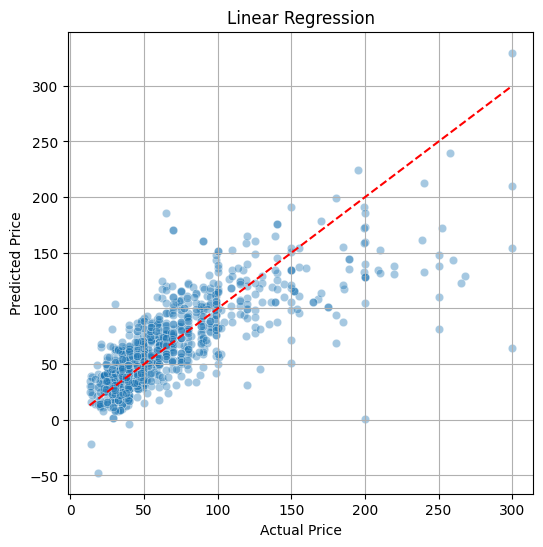

In [15]:
# Linear Regression

plot_results(y_test, y_pred_lr, "Linear Regression")

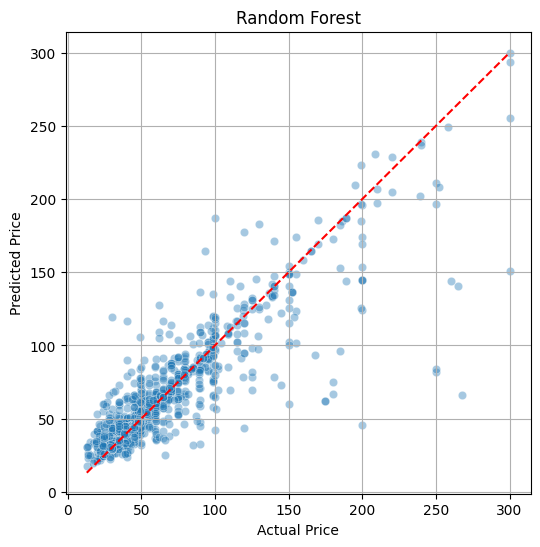

In [16]:
# Random Forest

plot_results(y_test, y_pred_rf, "Random Forest")

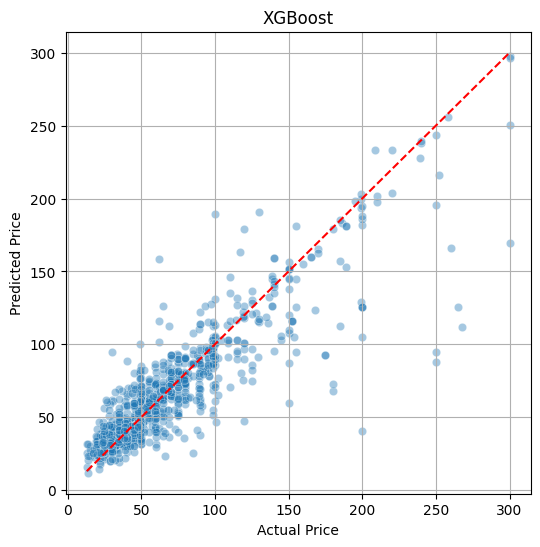

In [17]:
# XGBoost

plot_results(y_test, y_pred_xgb, "XGBoost")

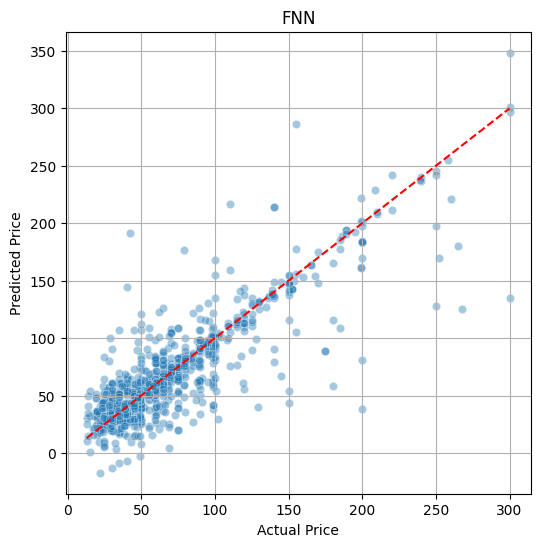

In [18]:
# FNN

plot_results(y_test, y_pred_fnn, "FNN")

In [19]:
# Comparison Table

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost", "FNN"],
    "R2": [r2_lr, r2_rf, r2_xgb, r2_fnn],
    "RMSE": [rmse_lr, rmse_rf, rmse_xgb, rmse_fnn]
})

results

,Model,R2,RMSE
0,Linear Regression,0.604369,29.308318
1,Random Forest,0.759079,22.870895
2,XGBoost,0.776538,22.026593
3,FNN,0.726225,24.380515


### Save Predictions :

In [20]:
linear_df = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": np.round(y_pred_lr, 2),
    "Error": np.round(y_pred_lr - y_test, 2)
})

linear_df.to_csv(
    "../../data/processed/linear_regression_predictions.csv",
    index=False
)

In [21]:
rf_df = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": np.round(y_pred_rf, 2),
    "Error": np.round(y_pred_rf - y_test, 2)
})

rf_df.to_csv(
    "../../data/processed/random_forest_predictions.csv",
    index=False
)

In [22]:
xgb_df = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": np.round(y_pred_xgb, 2),
    "Error": np.round(y_pred_xgb - y_test, 2)
})

xgb_df.to_csv(
    "../../data/processed/xgboost_predictions.csv",
    index=False
)

In [23]:
fnn_df = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": np.round(y_pred_fnn, 2),
    "Error": np.round(y_pred_fnn - y_test, 2)
})

fnn_df.to_csv(
    "../../data/processed/fnn_predictions.csv",
    index=False
)

### Error Analysis :

In [25]:
comparison_df = pd.DataFrame({
    "Actual": y_test,
    "Linear": y_pred_lr,
    "RandomForest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "FNN": y_pred_fnn
})

In [26]:
comparison_df.head()

,Actual,Linear,RandomForest,XGBoost,FNN
856,59.0,71.685713,58.105,61.740498,55.510621
3657,30.0,47.602823,34.325,40.695259,30.457306
4602,120.0,109.438590,94.625,118.149147,143.270606
4368,79.0,61.919229,67.100,62.467587,69.059967
3868,46.0,34.746406,46.010,42.466137,44.898430


In [27]:
comparison_df["LR_Error"] = comparison_df["Linear"] - comparison_df["Actual"]
comparison_df["RF_Error"] = comparison_df["RandomForest"] - comparison_df["Actual"]
comparison_df["XGB_Error"] = comparison_df["XGBoost"] - comparison_df["Actual"]

comparison_df.head(10)

,Actual,Linear,RandomForest,XGBoost,FNN,LR_Error,RF_Error,XGB_Error
856,59.0,71.685713,58.105,61.740498,55.510621,12.685713,-0.895,2.740498
3657,30.0,47.602823,34.325,40.695259,30.457306,17.602823,4.325,10.695259
4602,120.0,109.438590,94.625,118.149147,143.270606,-10.561410,-25.375,-1.850853
4368,79.0,61.919229,67.100,62.467587,69.059967,-17.080771,-11.900,-16.532413
3868,46.0,34.746406,46.010,42.466137,44.898430,-11.253594,0.010,-3.533863
2295,21.0,14.172590,25.115,23.181513,22.581329,-6.827410,4.115,2.181513
4239,65.0,70.194750,57.010,65.101128,85.420810,5.194750,-7.990,0.101128
2634,53.0,67.158187,60.330,58.751480,53.164437,14.158187,7.330,5.751480
350,50.0,71.113035,53.515,57.000294,59.893583,21.113035,3.515,7.000294
3017,60.0,72.556644,64.640,53.821320,80.937169,12.556644,4.640,-6.178680


### Classification (Superhost Prediction)

In [28]:
# Is Superhost_t
# (Features + Target)

# Features
X_clf = df.drop(columns=['Price', 'Is Superhost_t'])

# Target
y_clf = df['Is Superhost_t']

print(X_clf.shape, y_clf.shape)

(4970, 77) (4970,)


In [29]:
# Train / Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf   # مهم جدًا للتصنيف
)

print(X_train.shape, X_test.shape)

(3976, 77) (994, 77)


In [30]:
# missing values filling 

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [31]:
#  with random forest classifier

from sklearn.ensemble import RandomForestClassifier

clf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

clf_model.fit(X_train, y_train)

y_pred = clf_model.predict(X_test)

print("Classification model trained successfully!")

Classification model trained successfully!


In [32]:
# model evaluation

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.892354124748491

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       584
           1       0.88      0.85      0.87       410

    accuracy                           0.89       994
   macro avg       0.89      0.89      0.89       994
weighted avg       0.89      0.89      0.89       994



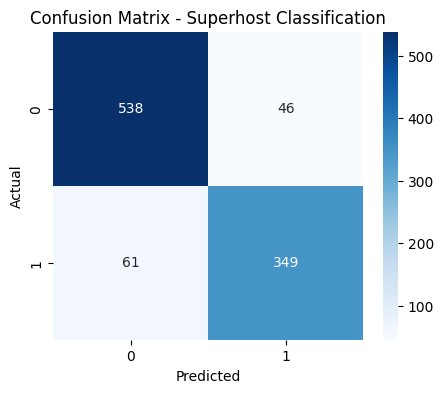

In [34]:
# Confusion Matrix

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Superhost Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
# Actual vs Predicted
comparison_clf = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison_clf.head(10)

,Actual,Predicted
3880,0,0
1232,1,1
3048,1,1
1258,0,1
3536,0,0
4649,0,0
63,0,0
4747,1,1
1084,1,1
2522,0,0


In [35]:
# save to csv
comparison_clf.to_csv("../../data/processed/superhost_predictions.csv", index=False)

print("Saved successfully!")

Saved successfully!
